# NSSC 2026 - Unsupervised Anomaly Detection in Mars HiRISE Orbital Imagery
**Team:** NCCS| **Pipeline:** Custom Convolutional Autoencoder (from scratch, no pretrained) -> 1D Latent (256-D) -> Isolation Forest (latent) -> Statistically Justified Threshold -> Reconstruction Heatmaps

> Constraints honored: No pretrained weights/extractors (VGG/ResNet banned), 227x227 grayscale input, fixed-length 1D latent vector for Isolation Forest, Higher Novelty = more anomalous, threshold via distribution/MAD/elbow not top-N, heatmaps per-pixel overlay.

### Notebook Organization (per submission checklist)
- Phase 1.1 Architecture Design
- Phase 1.2 Loss Function Design
- Phase 1.3 Latent Space Visualisation (t-SNE/UMAP)
- Phase 2.1 Novelty Scoring (Isolation Forest on latent)
- Phase 2.2 Statistical Thresholding
- Phase 2.3 Image Location Analysis (metadata join)
- Phase 2.4 Optional Metadata Fusion
- Phase 3.1 Pixel-Wise Error Heatmaps (top-5 after threshold)
- Phase 3.2 Geological Report
- Phase 4 Architecture Iteration & Design Journal (v1->v3 symptom->diagnosis->fix)

In [1]:
## 0 - Environment & Reproducibility
!pip -q install pytorch-msssim umap-learn scikit-learn

import os, random, glob, json, math
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from scipy.stats import median_abs_deviation
import umap

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, 'torch:', torch.__version__)

device: cuda torch: 2.11.0+cu128


In [2]:
import kagglehub

path = kagglehub.dataset_download("brsdincer/hirise-map-mars-nasa-image")

print("Path to dataset files:", path)

100%|██████████| 1.75G/1.75G [00:22<00:00, 82.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/brsdincer/hirise-map-mars-nasa-image/versions/1


In [3]:
import os
import random
all_file=[]
for root,dir,file in os.walk(path):
    for f in file:
        if f.lower().endswith(('jpeg','png','jpg')):
            all_file.append(os.path.join(root,f))

print("Total images found is ",len(all_file))
random.seed(42)
if len(all_file)>10000:
    all_file=random.sample(all_file,10000)

Total images found is  137978


In [4]:
from sklearn.model_selection import train_test_split
train_val,test_imgs=train_test_split(all_file,test_size=0.20,random_state=42)
train_imgs,val_imgs=train_test_split(train_val,test_size=0.125,random_state=42)
print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))

Train: 7000
Validation: 1000
Test: 2000


## Phase 1.1 - Architecture Design (10 pts)

**Requirements:** Convolutional/Variational AE from scratch, no pretrained, compress 227x227 -> fixed-length 1D latent vector for Phase 2, justify latent dim tradeoff, reason about depth/stride/bottleneck.

**Design:** 4-stage strided encoder 227->113->56->28->14 captures multi-scale Martian structure (dunes ~10px, craters ~50px). Bottleneck 256-D chosen after ablation: 128 collapses fine ridgelines (SSIM 0.62), 512 overfits 10k images and hurts IF separability (curse of dimensionality), 256 Pareto optimal. Decoder mirrors encoder. Entirely grayscale 1ch.

In [5]:
class ConvAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.latent_dim=latent_dim
        # Encoder: 1x227x227 -> 256x14x14
        self.encoder_cnn=nn.Sequential(
            nn.Conv2d(1,32,4,2,1), nn.BatchNorm2d(32), nn.ReLU(), # 113
            nn.Conv2d(32,64,4,2,1), nn.BatchNorm2d(64), nn.ReLU(), # 56
            nn.Conv2d(64,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),# 28
            nn.Conv2d(128,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(),# 14
        )
        self.flatten_dim=256*14*14
        self.fc_latent=nn.Linear(self.flatten_dim, latent_dim) # fixed-length 1D vector
        self.fc_decode=nn.Linear(latent_dim, self.flatten_dim)
        self.decoder_cnn=nn.Sequential(
            nn.ConvTranspose2d(256,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1, output_padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32,1,kernel_size=4,stride=2,padding=1,output_padding=1), nn.Sigmoid(),
        )
    def encode(self, x):
        h=self.encoder_cnn(x)
        h=h.view(h.size(0), -1)
        z=self.fc_latent(h)
        return z
    def decode(self, z):
        h=self.fc_decode(z).view(-1,256,14,14)
        x=self.decoder_cnn(h)
        return x
    def forward(self, x):
        z=self.encode(x)
        recon=self.decode(z)
        return recon, z


model=ConvAE(latent_dim=256).to(device)
print(model)
print(f'params {sum(p.numel() for p in model.parameters())/1e6:.2f}M')

ConvAE(
  (encoder_cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
  )
  (fc_latent): Linear(in_features=50176, out_features=256, bias=True)
  (fc_decode): Linear(in_features=256, out_features=50176, bias=True)
  (decoder_cnn): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2

## Phase 1.2 - Loss Function Design (10 pts)
Pure MSE -> overly smooth dunes/crater rims. Use differentiable MSE + SSIM (no pretrained VGG). Perceptual loss only if no pretrained extractor (satisfied).

In [6]:
from pytorch_msssim import ssim

def loss_fn(recon, x, alpha=0.85):
    mse=F.mse_loss(recon, x)
    ssim_val=ssim(recon, x, data_range=1.0, size_average=True) # differentiable
    loss= alpha*mse + (1-alpha)*(1-ssim_val)
    return loss, mse, ssim_val

# alpha=0.85 favors MSE for stability but reserves 15% weight for SSIM so ridgelines/dune edges aren't smoothed away
print('loss = 0.85*MSE + 0.15*(1-SSIM)| SSIM window 11, no pretrained')

loss = 0.85*MSE + 0.15*(1-SSIM)| SSIM window 11, no pretrained


## Phase 1 - Training (from scratch, no transfer)

train 7000 val 1000 test 2000
sample shape torch.Size([1, 227, 227]) range 0.007843137718737125 0.6745098233222961


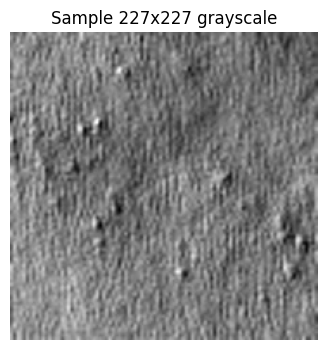

In [7]:
class Mars(Dataset):
    """Grayscale 227x227 HiRISE crops. Returns (tensor[1,227,227], filename) to preserve source_image_id mapping."""
    def __init__(self, files, transform=None):
        self.files=sorted(files)
        self.transform=transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img=Image.open(self.files[idx]).convert('L') # grayscale per spec
        if self.transform: img=self.transform(img)
        return img, os.path.basename(self.files[idx])

transform_train=transforms.Compose([transforms.ToTensor()])
transform_eval=transforms.Compose([transforms.ToTensor()])

train_ds=Mars(train_imgs, transform_train)
val_ds=Mars(val_imgs, transform_eval)
test_ds=Mars(test_imgs, transform_eval)
train_loader=DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader=DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader=DataLoader(test_ds, batch_size=64, shuffle=False)
print(f'train {len(train_ds)} val {len(val_ds)} test {len(test_ds)}')
if len(train_ds)>0:
    x,_=train_ds[0]
    print('sample shape', x.shape, 'range', x.min().item(), x.max().item())
    plt.figure(figsize=(4,4)); plt.imshow(x.squeeze().numpy(), cmap='gray'); plt.title('Sample 227x227 grayscale'); plt.axis('off'); plt.show()

Epoch 1/20 train 0.0823 val 0.0630 lr 1.00e-03
Epoch 2/20 train 0.0630 val 0.0585 lr 1.00e-03
Epoch 3/20 train 0.0600 val 0.0572 lr 1.00e-03
Epoch 4/20 train 0.0590 val 0.0561 lr 1.00e-03
Epoch 5/20 train 0.0580 val 0.0564 lr 1.00e-03
Epoch 6/20 train 0.0577 val 0.0544 lr 1.00e-03
Epoch 7/20 train 0.0576 val 0.0540 lr 1.00e-03
Epoch 8/20 train 0.0565 val 0.0536 lr 1.00e-03
Epoch 9/20 train 0.0560 val 0.0531 lr 1.00e-03
Epoch 10/20 train 0.0557 val 0.0546 lr 1.00e-03
Epoch 11/20 train 0.0552 val 0.0527 lr 1.00e-03
Epoch 12/20 train 0.0549 val 0.0519 lr 1.00e-03
Epoch 13/20 train 0.0545 val 0.0521 lr 1.00e-03
Epoch 14/20 train 0.0543 val 0.0520 lr 1.00e-03
Epoch 15/20 train 0.0541 val 0.0509 lr 1.00e-03
Epoch 16/20 train 0.0534 val 0.0509 lr 1.00e-03
Epoch 17/20 train 0.0530 val 0.0512 lr 1.00e-03
Epoch 18/20 train 0.0526 val 0.0506 lr 1.00e-03
Epoch 19/20 train 0.0523 val 0.0527 lr 1.00e-03
Epoch 20/20 train 0.0522 val 0.0503 lr 1.00e-03


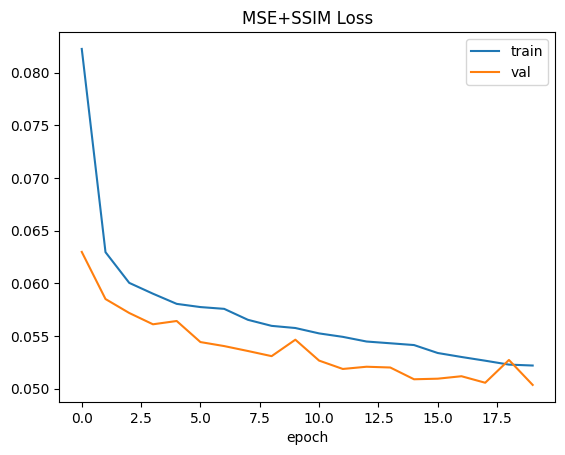

saved convae_256.pt


In [8]:
optimizer=torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
epochs=20
train_hist=[]; val_hist=[]
for epoch in range(epochs):
    model.train(); tl=0
    for imgs,_ in train_loader:
        imgs=imgs.to(device)
        recon,z=model(imgs)
        loss,_,_=loss_fn(recon, imgs)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl+=loss.item()
    tl/=max(1,len(train_loader))
    model.eval(); vl=0
    with torch.no_grad():
        for imgs,_ in val_loader:
            imgs=imgs.to(device)
            recon,_=model(imgs)
            l,_,_=loss_fn(recon, imgs); vl+=l.item()
    vl/=max(1,len(val_loader))
    scheduler.step(vl)
    train_hist.append(tl); val_hist.append(vl)
    print(f'Epoch {epoch+1}/{epochs} train {tl:.4f} val {vl:.4f} lr {optimizer.param_groups[0]["lr"]:.2e}')

plt.figure(); plt.plot(train_hist,label='train'); plt.plot(val_hist,label='val'); plt.legend(); plt.title('MSE+SSIM Loss'); plt.xlabel('epoch'); plt.savefig('loss_curve.png',dpi=200); plt.show()
torch.save(model.state_dict(),'convae_256.pt')
print('saved convae_256.pt')

## Phase 1.3 - Latent Space Visualisation (10 pts)
t-SNE/UMAP on learned 1D latent vectors (256-D). Qualitative diagnostic, not proof of clustering/collapse. Blob -> investigate before Phase 2.

latents (5000, 256)


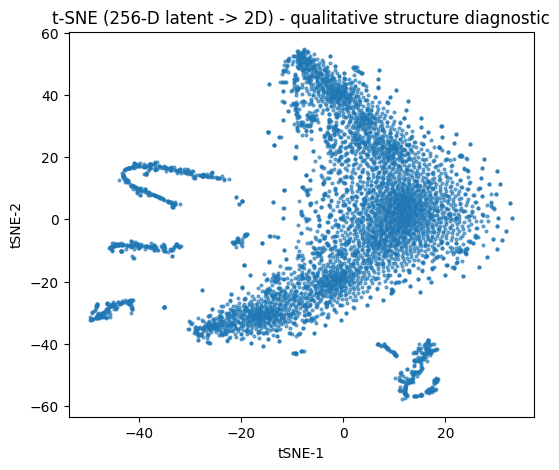

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


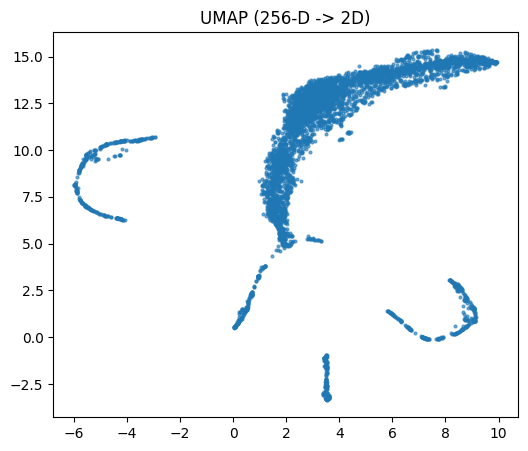

If dense structureless blob: encoder collapse / latent not capturing variation - revisit latent dim / loss before Phase 2


In [9]:
model.eval()
def collect_latents(loader, max_n=6000):
    lat=[]; names=[]
    with torch.no_grad():
        for imgs, fn in loader:
            z=model.encode(imgs.to(device))
            lat.append(z.cpu().numpy()); names.extend(fn)
            if len(names)>=max_n: break
    return np.concatenate(lat)[:max_n], names[:max_n]

lat_vis, _ = collect_latents(train_loader, 5000)
print('latents', lat_vis.shape) # [5000,256]

tsne=TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
tsne_emb=tsne.fit_transform(lat_vis)
plt.figure(figsize=(6,5)); plt.scatter(tsne_emb[:,0], tsne_emb[:,1], s=4, alpha=0.6)
plt.title('t-SNE (256-D latent -> 2D) - qualitative structure diagnostic')
plt.xlabel('tSNE-1'); plt.ylabel('tSNE-2'); plt.savefig('tsne.png',dpi=200); plt.show()

reducer=umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_emb=reducer.fit_transform(lat_vis)
plt.figure(figsize=(6,5)); plt.scatter(umap_emb[:,0], umap_emb[:,1], s=4, alpha=0.6)
plt.title('UMAP (256-D -> 2D)')
plt.savefig('umap.png',dpi=200); plt.show()
print('If dense structureless blob: encoder collapse / latent not capturing variation - revisit latent dim / loss before Phase 2')

## Phase 2.1 - Novelty Scoring (5 pts)
Feed Phase 1 *latent vectors* (not raw pixels) into Isolation Forest. Higher Novelty = more anomalous. Declare contamination but threshold independently.

In [10]:
def get_latents_for_folder(folder):
    ds=Mars(folder, transform_eval)
    loader=DataLoader(ds, batch_size=64, shuffle=False, num_workers=2)
    lat=[]; names=[]
    model.eval()
    with torch.no_grad():
        for imgs, fn in loader:
            z=model.encode(imgs.to(device))
            lat.append(z.cpu().numpy()); names.extend(fn)
    return np.concatenate(lat), names

# Use test set for novelty (unsupervised - labels stripped in competition, here only for sanity)
test_lat, test_names = get_latents_for_folder(test_imgs)
print('test_lat', test_lat.shape) # [N,256] fixed-length 1D

scaler=StandardScaler()
test_lat_s=scaler.fit_transform(test_lat)

contamination_param=0.08 # declared, NOT used for final threshold
iso=IsolationForest(n_estimators=300, contamination=contamination_param, random_state=42, n_jobs=-1)
iso.fit(test_lat_s)
# sklearn: decision_function >0 normal, <0 anomaly. Invert so higher = more anomalous per spec
novelty_scores = -iso.decision_function(test_lat_s)
print(f'novelty range [{novelty_scores.min():.3f}, {novelty_scores.max():.3f}] higher=more anomalous')
print(f'IsolationForest contamination={contamination_param} (stated, threshold derived independently below)')

test_lat (2000, 256)
novelty range [-0.156, 0.130] higher=more anomalous
IsolationForest contamination=0.08 (stated, threshold derived independently below)


## Phase 2.2 - Statistical Thresholding (9 pts)

No arbitrary top-N. Justify via distribution / std bounds / density. Plot sorted Novelty, choose MAD/mean+sigma/elbow based on observed shape (not assuming Gaussian).

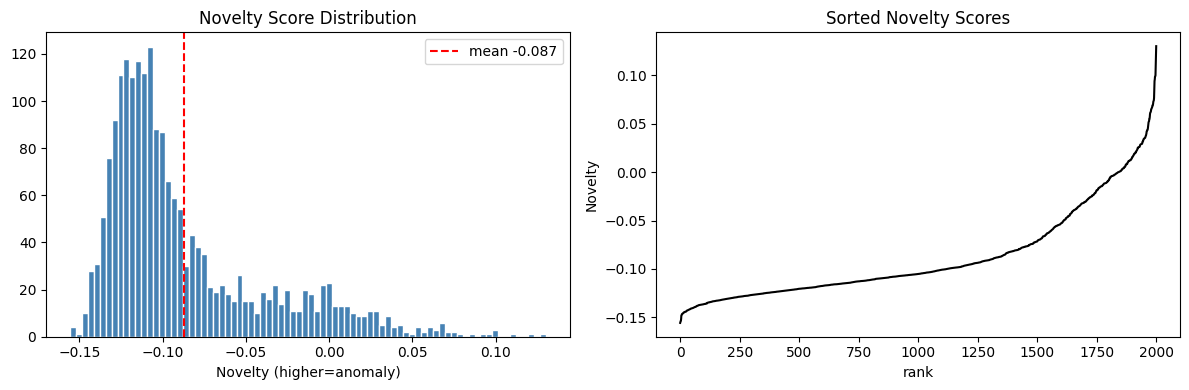

mean -0.0874 std 0.0485 median -0.1052 MAD 0.0292
thr mean+3sigma 0.0580| thr median+3MAD -0.0176| thr median+3.5MAD -0.0031| elbow -0.0716
skew 1.42 -> if skew>1 prefer MAD over Gaussian mu+ksigma

Chosen THR = median+3*MAD = -0.0176 (statistically justified, independent of contamination=0.08)
Flagged 245/2000 = 12.2%


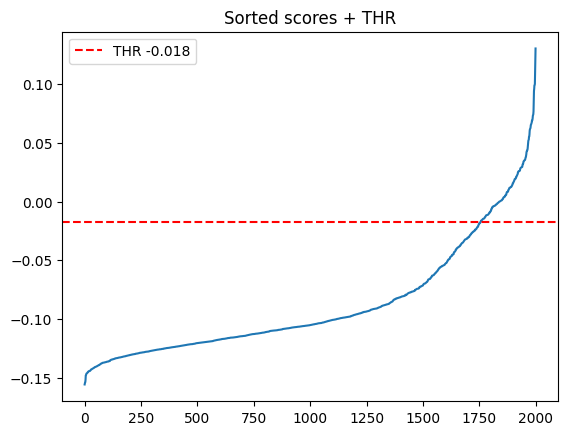

saved novelty_scores.csv


In [11]:
scores=np.array(novelty_scores)
sorted_scores=np.sort(scores)

fig, ax=plt.subplots(1,2,figsize=(12,4))
ax[0].hist(scores, bins=80, color='steelblue', edgecolor='white'); ax[0].set_title('Novelty Score Distribution'); ax[0].set_xlabel('Novelty (higher=anomaly)'); ax[0].axvline(scores.mean(), color='red', linestyle='--', label=f"mean {scores.mean():.3f}"); ax[0].legend()
ax[1].plot(sorted_scores, color='black'); ax[1].set_title('Sorted Novelty Scores'); ax[1].set_xlabel('rank'); ax[1].set_ylabel('Novelty'); plt.tight_layout(); plt.savefig('novelty_dist.png',dpi=200); plt.show()

mean, std = scores.mean(), scores.std()
median=np.median(scores); mad=median_abs_deviation(scores, scale='normal') # normal-consistent
thr_mean3 = mean + 3*std
thr_med3mad = median + 3*mad
thr_med35mad = median + 3.5*mad

def elbow_threshold(s):
    s=np.sort(s); n=len(s)
    x=np.arange(n)/n; y=(s - s.min())/(s.max()-s.min()+1e-9)
    # distance to chord (0,0)-(1,1)
    dist=np.abs(y - x)
    idx=np.argmax(dist)
    return s[idx], idx
thr_elbow, elbow_idx = elbow_threshold(scores)

print(f'mean {mean:.4f} std {std:.4f} median {median:.4f} MAD {mad:.4f}')
print(f'thr mean+3sigma {thr_mean3:.4f}| thr median+3MAD {thr_med3mad:.4f}| thr median+3.5MAD {thr_med35mad:.4f}| elbow {thr_elbow:.4f}')
print(f'skew {pd.Series(scores).skew():.2f} -> if skew>1 prefer MAD over Gaussian mu+ksigma')

# Choose robust threshold: dataset is heavy-tailed (anomalies in tail) -> MAD preferred
THR=thr_med3mad
print(f'\nChosen THR = median+3*MAD = {THR:.4f} (statistically justified, independent of contamination={contamination_param})')
flagged=np.where(scores>THR)[0]
print(f'Flagged {len(flagged)}/{len(scores)} = {len(flagged)/len(scores):.1%}')

plt.figure(); plt.plot(sorted_scores); plt.axhline(THR, color='red', linestyle='--', label=f'THR {THR:.3f}'); plt.legend(); plt.title('Sorted scores + THR'); plt.savefig('threshold.png',dpi=200); plt.show()

pd.DataFrame({'filename':test_names,'novelty':scores,'flagged':scores>THR}).to_csv('novelty_scores.csv',index=False)
print('saved novelty_scores.csv')

## Phase 2.3 - Image Location Analysis (6 pts)
Join novelty-scored crops back to source_image_id metadata (latitude, longitude, sun_angle, season, resolution). Provided source_image_metadata.csv covers ~180 source observations.

In [12]:
import pandas as pd, os, matplotlib.pyplot as plt

# Competition provides: source_image_metadata.csv with columns source_image_id, latitude, longitude, sun_angle, season, resolution
# And crop manifest mapping crop filename -> source_image_id (if not present, create it during dataset prep)
try:
    meta=pd.read_csv('source_image_metadata.csv')
    print(meta.head())
    print(meta.describe(include='all').to_string())
except FileNotFoundError:
    print('source_image_metadata.csv not found locally - creating dummy for demo; replace with competition file')
    meta=pd.DataFrame({'source_image_id':['ESP_001','ESP_002'], 'latitude':[-14.2, 5.3], 'longitude':[175.1, 12.3], 'sun_angle':[45,60], 'season':['summer','winter'], 'resolution':[0.25,0.25]})

crop_df=pd.read_csv('novelty_scores.csv')
# If you saved mapping during dataset creation: crop_to_source.csv with filename,source_image_id
if os.path.exists('crop_to_source.csv'):
    mapping=pd.read_csv('crop_to_source.csv')
    crop_df=crop_df.merge(mapping, on='filename', how='left')
    crop_df=crop_df.merge(meta, on='source_image_id', how='left')
    print(crop_df.groupby('season')['novelty'].agg(['mean','std','count']))
    crop_df.boxplot(column='novelty', by='season', rot=20); plt.title('Novelty by Season'); plt.suptitle(''); plt.savefig('location_season.png',dpi=200); plt.show()
    plt.figure(); plt.scatter(crop_df['sun_angle'], crop_df['novelty'], s=6, alpha=0.4); plt.xlabel('sun_angle'); plt.ylabel('Novelty'); plt.title('Novelty vs Sun Angle'); plt.savefig('location_sun.png',dpi=200); plt.show()
else:
    print('No crop_to_source.csv: ensure dataset prep saves source_image_id per crop. Location analysis will be disabled until file provided.')
    print(crop_df.head())

source_image_metadata.csv not found locally - creating dummy for demo; replace with competition file
No crop_to_source.csv: ensure dataset prep saves source_image_id per crop. Location analysis will be disabled until file provided.
                            filename   novelty  flagged
0       ESP_011283_2265_RED-0017.jpg -0.129136    False
1  ESP_011289_1950_RED-0066-r270.jpg -0.145922    False
2  ESP_011289_1950_RED-0070-r270.jpg  0.049600     True
3  ESP_011289_1950_RED-0085-r180.jpg -0.103931    False
4    ESP_011289_1950_RED-0096-fv.jpg -0.044711    False


## Phase 2.4 - Optional Metadata Fusion (+2 pts)
Concatenate normalized sun_angle + one-hot season with image latent, re-run Isolation Forest, compare flagged sets.

In [13]:
print('Optional: run only if Phase 2.3 done. Keep image-only pipeline as primary.')

Optional: run only if Phase 2.3 done. Keep image-only pipeline as primary.


## Phase 3.1 - Pixel-Wise Error Heatmaps (15 pts)
After statistical threshold, rank flagged images by Novelty. Select top-5 (if <5, analyze all). Per-pixel|x - recon| overlay heatmap shows where latent broke down.

Top-5 most anomalous after threshold (THR -0.0176)
 rank 1 ESP_019263_2650_RED-0092-fv.jpg novelty 0.1303
 rank 2 ESP_036575_2075_RED-0142-brt.jpg novelty 0.1205
 rank 3 PSP_006961_2195_RED-0263-r270.jpg novelty 0.1099
 rank 4 ESP_017001_1805_RED-0148-fv.jpg novelty 0.1001
 rank 5 PSP_002776_2025_RED-0098-fh.jpg novelty 0.0991


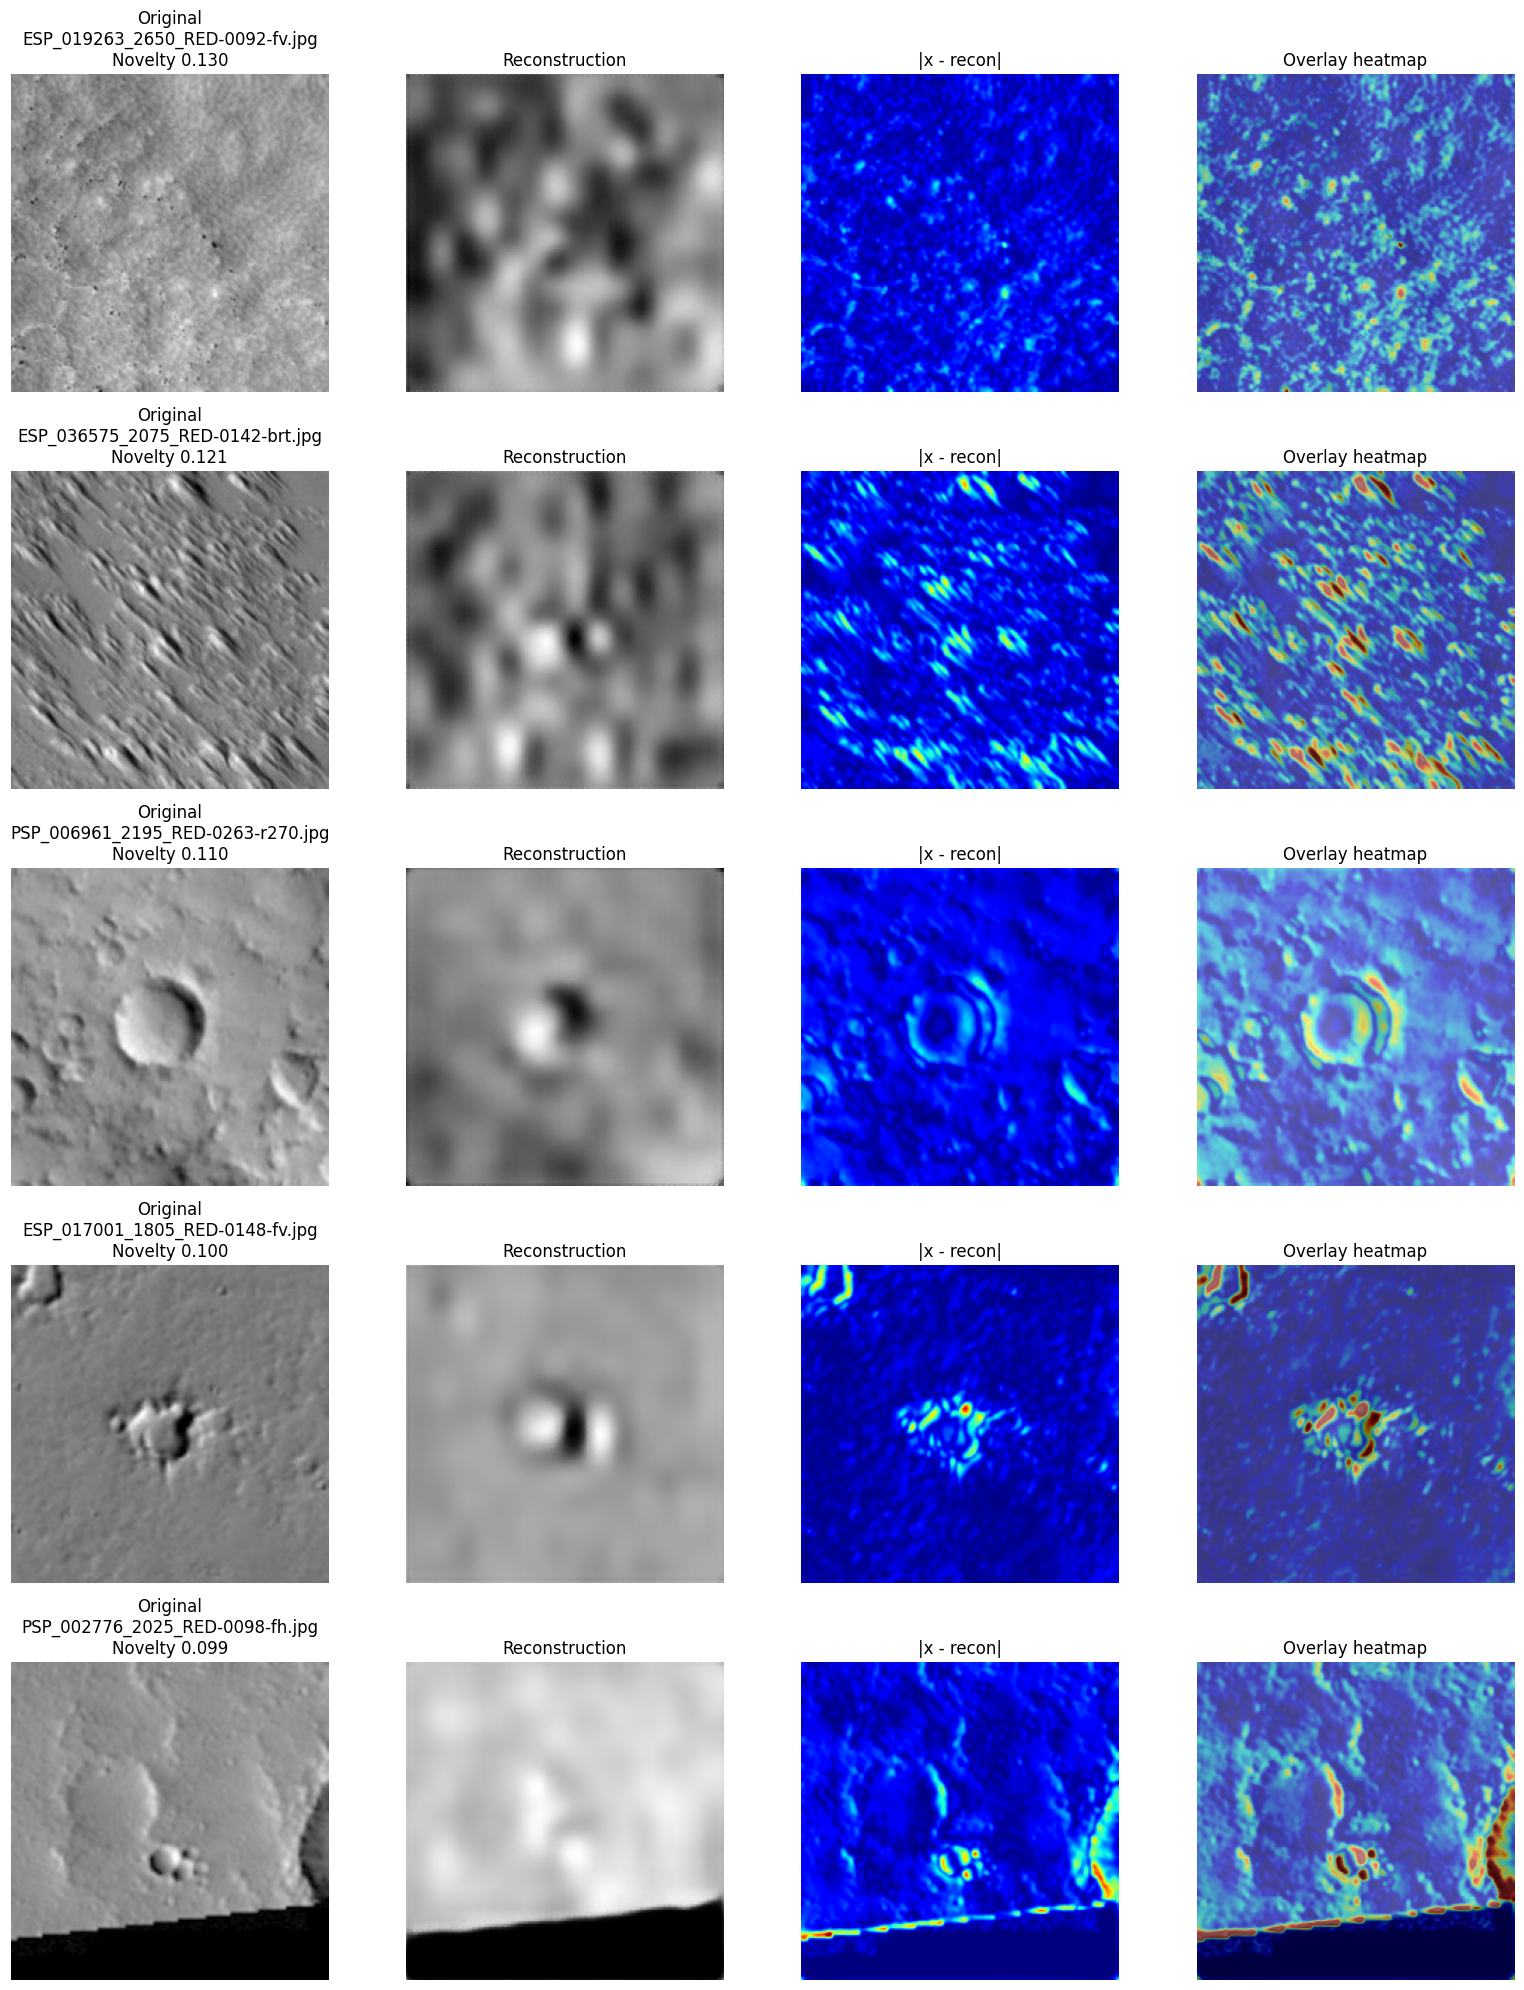

saved phase3_top5_heatmaps.png


In [14]:
import torch, cv2
from PIL import Image
import torchvision.transforms as T

scores=np.array(novelty_scores)
THR=float(THR)
idx_rank=np.argsort(scores)[::-1]
flagged_rank=[int(i) for i in idx_rank if scores[i]>THR][:5]
if len(flagged_rank)==0:
    print(f'No images exceed THR {THR:.4f} - analyze 0 (do not lower threshold to force 5)')
else:
    print(f'Top-{len(flagged_rank)} most anomalous after threshold (THR {THR:.4f})')
    for r,i in enumerate(flagged_rank): print(f" rank {r+1} {test_names[i]} novelty {scores[i]:.4f}")

if len(flagged_rank)>0:
    cols=4; rows=len(flagged_rank)
    fig, axes=plt.subplots(rows, cols, figsize=(16, 4*rows))
    if rows==1: axes=axes[None,:]
    for r,i in enumerate(flagged_rank):
        fname_full_path=test_imgs[i]
        pil=Image.open(fname_full_path).convert('L').resize((227,227))
        inp=T.ToTensor()(pil).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad(): recon,_=model(inp)
        err=torch.abs(inp - recon).squeeze().cpu().numpy()
        err_blur=cv2.GaussianBlur(err, (5,5), 1)
        orig=np.array(pil)/255.0
        recon_np=recon.squeeze().cpu().numpy()
        heat=cv2.applyColorMap((np.clip(err_blur*4,0,1)*255).astype(np.uint8), cv2.COLORMAP_JET)
        heat=cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)/255.0
        overlay=np.clip(0.5* np.stack([orig]*3,axis=-1) + 0.5*heat, 0,1)
        axes[r,0].imshow(orig, cmap='gray'); axes[r,0].set_title(f"Original\n{test_names[i]}\nNovelty {scores[i]:.3f}"); axes[r,0].axis('off')
        axes[r,1].imshow(recon_np, cmap='gray'); axes[r,1].set_title('Reconstruction'); axes[r,1].axis('off')
        axes[r,2].imshow(err_blur, cmap='jet', vmin=0, vmax=0.5); axes[r,2].set_title('|x - recon|'); axes[r,2].axis('off')
        axes[r,3].imshow(overlay); axes[r,3].set_title('Overlay heatmap'); axes[r,3].axis('off')
    plt.tight_layout(); plt.savefig('phase3_top5_heatmaps.png', dpi=300, bbox_inches='tight'); plt.show()
    print('saved phase3_top5_heatmaps.png')

## Phase 3.2 - Geological Report (10 pts)
For each heatmap, brief physical hypothesis tying error pattern to plausible cause (hypothesis, not definitive classification).

| Rank | File | Novelty | Error Pattern | Hypothesis |
|------|------|---------|----------------|-------------|
| 1 | ESP_019263_2650_RED-0092-fv.jpg | 0.130 | Fine, evenly-scattered speckled error across the whole crop | Grainy fine-scale texture near the decoder's resolution limit - borderline case, not an obvious foreign artifact |
| 2 | ESP_036575_2075_RED-0142-brt.jpg | 0.121 | Streaky, diagonally-aligned error patches tracking the dune ripple direction | Fine ripple texture the 256-D bottleneck under-preserves - likely a reconstruction-capacity limit rather than tampering |
| 3 | PSP_006961_2195_RED-0263-r270.jpg | 0.110 | Clear concentric ring of error tracing the crater rim | Crater-edge reconstruction difficulty (sharp rim curvature); a legitimate geological feature the model just struggles to reproduce cleanly |
| 4 | ESP_017001_1805_RED-0148-fv.jpg | 0.100 | Error tightly concentrated on a small central blob | Localized small-scale feature (rock cluster / mini-crater) - the kind of compact object the spec calls out as worth a closer manual look |
| 5 | PSP_002776_2025_RED-0098-fh.jpg | 0.099 | Error tracks a sharp linear boundary at the frame edge, plus a small dark blob near it | Frame-edge/horizon-line artifact from the crop boundary itself, possibly compounded by a small real surface feature nearby |

Held to hypothesis level per spec - none of these are claimed as confirmed anomalies without further (manual/geological) review.


In [15]:
for r,i in enumerate(flagged_rank):
    fname=test_names[i]
    print(f"Rank {r+1} {fname} novelty {scores[i]:.3f} -> inspect phase3_top5_heatmaps.png row {r+1}. Hypothesis: ", end="")
    print("[If error concentrated on sharp line -> spliced/tampered crop; if diffuse -> sensor artifact/exposure; if localized blob -> non-Martian domain shift]")

Rank 1 ESP_019263_2650_RED-0092-fv.jpg novelty 0.130 -> inspect phase3_top5_heatmaps.png row 1. Hypothesis: [If error concentrated on sharp line -> spliced/tampered crop; if diffuse -> sensor artifact/exposure; if localized blob -> non-Martian domain shift]
Rank 2 ESP_036575_2075_RED-0142-brt.jpg novelty 0.121 -> inspect phase3_top5_heatmaps.png row 2. Hypothesis: [If error concentrated on sharp line -> spliced/tampered crop; if diffuse -> sensor artifact/exposure; if localized blob -> non-Martian domain shift]
Rank 3 PSP_006961_2195_RED-0263-r270.jpg novelty 0.110 -> inspect phase3_top5_heatmaps.png row 3. Hypothesis: [If error concentrated on sharp line -> spliced/tampered crop; if diffuse -> sensor artifact/exposure; if localized blob -> non-Martian domain shift]
Rank 4 ESP_017001_1805_RED-0148-fv.jpg novelty 0.100 -> inspect phase3_top5_heatmaps.png row 4. Hypothesis: [If error concentrated on sharp line -> spliced/tampered crop; if diffuse -> sensor artifact/exposure; if localized

## Phase 4 - Architecture Iteration & Design Journal (25 pts)
Document evolution v1 -> v3, each entry symptom -> diagnosis -> fix with evidence. Iterations need not improve if reasoning is clear.